# Import Librares

In [1]:
import numpy as np
import pandas as pd

from sklearn.feature_selection import RFE

from sklearn.ensemble import RandomForestClassifier

# Import Dataset using read_csv method

In [2]:
url ="https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/refs/heads/master/data/Telco-Customer-Churn.csv" 

df = pd.read_csv(url)

In [3]:
#Set option to display all rows and column

pd.set_option("display.max_rows",None) #load all columns as is
pd.set_option("display.max_columns",None) #load all columns as is

#View the top 5 rows of dataset
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
#Checking information about data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [7]:
df['gender'] = df['gender'].map({"Female":0, "Male":1})

In [8]:
df['gender'].value_counts()

gender
1    3555
0    3488
Name: count, dtype: int64

In [9]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df['Churn'] = df['Churn'].map({"No":0, "Yes":1})

In [11]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [12]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [13]:
df.isnull().sum() # this is bad

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df.dropna(inplace=True)

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [16]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


In [17]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [18]:
numerical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 
                      'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                      'DeviceProtection','TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                      'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

In [19]:
for col in numerical_features:
    if df[col].dtype == "object":
        df[col] = pd.factorize(df[col])[0]

#X = df[Input_features]
#X = pd.get_dummies(X,columns=X.select_dtypes(include='object').columns, drop_first=True,dtype=int)

In [20]:
numerical_features = [f for f in numerical_features if f in df.columns]
numerical_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges']

In [21]:
X = df[numerical_features]

y = df['Churn']

In [22]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,29.85,29.85
1,1,0,1,0,34,1,1,0,1,1,1,0,0,0,1,1,1,56.95,1889.50
2,1,0,1,0,2,1,1,0,1,0,0,0,0,0,0,0,1,53.85,108.15
3,1,0,1,0,45,0,0,0,1,1,1,1,0,0,1,1,2,42.30,1840.75
4,0,0,1,0,2,1,1,1,0,1,0,0,0,0,0,0,0,70.70,151.65


In [23]:
X.shape


(7032, 19)

In [24]:
y.shape

(7032,)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, stratify=y,random_state=42)

In [26]:
rf = RandomForestClassifier(n_estimators=200)

rfe = RFE(estimator=rf, n_features_to_select=5) #6,7,8

In [27]:
rfe.fit(X_train,y_train) #use only train data

RFE(estimator=RandomForestClassifier(n_estimators=200), n_features_to_select=5)

In [28]:
rfe.support_

array([False, False, False, False,  True, False, False, False,  True,
       False, False, False, False, False,  True, False, False,  True,
        True])

In [29]:
X.columns[rfe.support_]

Index(['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges',
       'TotalCharges'],
      dtype='object')

In [30]:
selected_features = [f for f,sel in zip(X,rfe.support_) if sel] 

In [31]:
selected_features

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

In [32]:
X_train_rfe = rfe.transform(X_train)
X_test_rfe = rfe.transform(X_test)

In [33]:
rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [34]:
rf_final.fit(X_train_rfe, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [35]:
importances = pd.DataFrame({'feature':selected_features, 'importance':rf_final.feature_importances_})

In [36]:
importances = importances.sort_values('importance',ascending=False)

importances

,feature,importance
3,MonthlyCharges,0.325034
4,TotalCharges,0.311934
0,tenure,0.182077
2,Contract,0.114741
1,OnlineSecurity,0.066214


<Axes: xlabel='importance', ylabel='feature'>

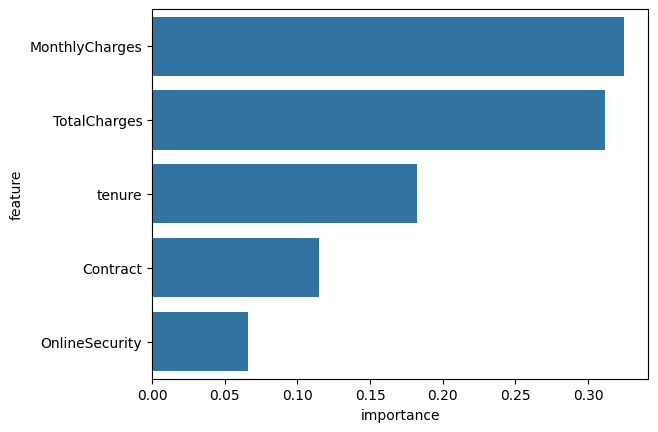

In [37]:
import seaborn as sns

sns.barplot(x='importance',y='feature',data=importances)

In [38]:
selected_features

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

In [39]:
from sklearn.preprocessing import StandardScaler

#model building

X = df[selected_features]

y = df['Churn']

In [40]:
X_train,X_test, y_train, y_test = train_test_split(X,y, test_size=0.20,stratify=y,random_state=42)

In [41]:
scaler = StandardScaler()

In [42]:
import pickle

In [43]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler,f)

In [44]:
import tensorflow as tf

from tensorflow.keras import layers, models

2026-06-06 07:16:48.570394: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780730208.754353      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780730208.809328      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780730209.253699      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780730209.253741      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780730209.253744      22 computation_placer.cc:177] computation placer alr

In [45]:
def create_model():
    model = models.Sequential([
        layers.Dense(64, activation='relu',input_shape = (5,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16,activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy']) 
    return model

In [46]:
ann_model = create_model()

ann_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1780730221.200728      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = ann_model.fit(X_train_scaled, y_train,epochs=50,batch_size=32,validation_split=0.20,)

Epoch 1/50


I0000 00:00:1780730223.799616      79 service.cc:152] XLA service 0x7cace000e280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780730223.799698      79 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1780730224.133559      79 cuda_dnn.cc:529] Loaded cuDNN version 91002


 74/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7424 - loss: 0.5608

I0000 00:00:1780730224.835906      79 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7762 - loss: 0.4757 - val_accuracy: 0.7796 - val_loss: 0.4343
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4353 - val_accuracy: 0.7822 - val_loss: 0.4246
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4275 - val_accuracy: 0.7858 - val_loss: 0.4240
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7969 - loss: 0.4263 - val_accuracy: 0.7893 - val_loss: 0.4190
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7973 - loss: 0.4255 - val_accuracy: 0.7831 - val_loss: 0.4225
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8022 - loss: 0.4225 - val_accuracy: 0.7858 - val_loss: 0.4179
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8013 - loss: 0.4213 - val_accuracy: 0.7867 - val_loss: 0.4181
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8009 - loss: 0.4213 - val_accuracy: 0.7893 - val

Text(0, 0.5, 'Loss')

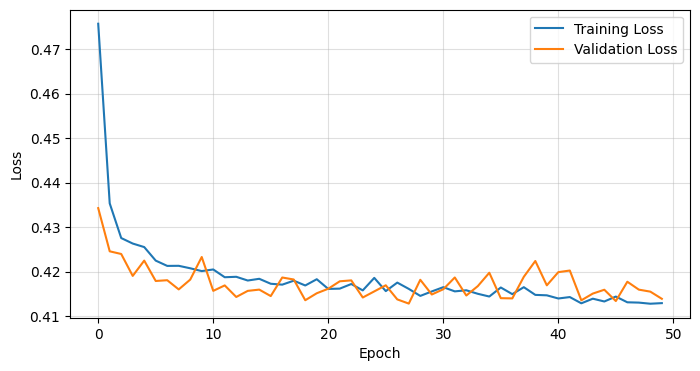

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.grid(alpha=0.4)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")



Text(0, 0.5, 'Accuracy')

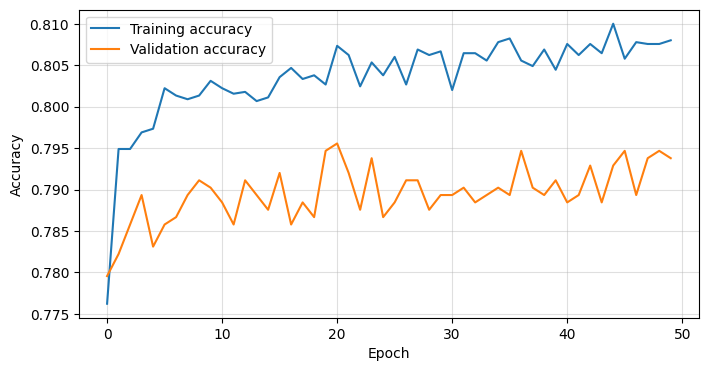

In [49]:

plt.figure(figsize=(8,4))

plt.plot(history.history['accuracy'], label='Training accuracy')

plt.plot(history.history['val_accuracy'], label='Validation accuracy')

plt.grid(alpha=0.4)

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

In [50]:
!pip install keras-tuner

In [51]:
import keras_tuner as kt

In [52]:
def build_model(hp):
    
    model = models.Sequential()
    
    n_layers = hp.Int('n_layers',min_value=1,max_value=4, step=1)
    
    for i in range(n_layers):
        model.add(layers.Dense(units = hp.Int(f"units_{i}", min_value=16, max_value=256, step=16), 
                               activation = hp.Choice(f"activation_{i}", values=['relu','tanh','elu']), 
                               kernel_regularizer = tf.keras.regularizers.l2(hp.Float(f"lr_{i}", min_value=1e-5, 
                                                    max_value=1e-2, sampling='log')))) 
    model.add(layers.Dropout(rate = hp.Float(f"dropout_{i}", min_value=0.0, max_value=0.5, step=0.1)))
    model.add(layers.Dense(1, activation='sigmoid'))
    
    #learning rate and oiptimser
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log') 
    optimizer = hp.Choice('optimizer',values=['adam','rmsprop','sgd'])
    
    if optimizer == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate) 
    elif optimizer == "rmsprop":
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate) 
    else:
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate,momentum=0.9)
    
    model.compile(optimizer=opt, loss='binary_crossentropy',metrics=['accuracy']) 
    
    return model

In [53]:
tuner = kt.BayesianOptimization(hypermodel = build_model, 
                                objective='val_accuracy', 
                                max_trials = 20, 
                                num_initial_points=5, 
                                #random 
                                seed = 10, 
                                directory = 'keras_tuner_logs', 
                                project_name = "misson_ai_sekho" 
                               )


In [54]:
tuner.search_space_summary()

Search space summary
Default search space size: 7
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 4, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 256, 'step': 16, 'sampling': 'linear'}
activation_0 (Choice)
{'default': 'relu', 'conditions': [], 'values': ['relu', 'tanh', 'elu'], 'ordered': False}
lr_0 (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-05, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
dropout_0 (Float)
{'default': 0.0, 'conditions': [], 'min_value': 0.0, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}
optimizer (Choice)
{'default': 'adam', 'conditions': [], 'values': ['adam', 'rmsprop', 'sgd'], 'ordered': False}


In [55]:
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5)

In [56]:
tuner.search(X_train_scaled, y_train, 
             epochs=50, 
             batch_size=32, 
             validation_split = 0.20, 
             callbacks=[stop_early] 
            )



Trial 20 Complete [00h 00m 07s]
val_accuracy: 0.800000011920929

Best val_accuracy So Far: 0.8017777800559998
Total elapsed time: 00h 06m 09s


In [57]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

In [58]:
best_hps

In [59]:

for i in range(best_hps.get('n_layers')): 
    print(f" Layer {i+1} units : {best_hps.get(f'units_{i}')}") 
    print(f" Layer {i+1} activation : {best_hps.get(f'activation_{i}')}") 
    print(f" Layer {i+1} dropout : {best_hps.get(f'dropout_{i}')}") 
    print(f" Layer {i+1} L2 : {best_hps.get(f'lr_{i}')}") 
    print(f" Optimizer : {best_hps.get(f'optimizer')}") 
    print(f" Learning Rate : {best_hps.get(f'learning_rate')}")



 Layer 1 units : 240
 Layer 1 activation : tanh
 Layer 1 dropout : 0.0
 Layer 1 L2 : 0.0004410354359965501
 Optimizer : adam
 Learning Rate : 0.0009887195863122636
 Layer 2 units : 256
 Layer 2 activation : tanh
 Layer 2 dropout : 0.0
 Layer 2 L2 : 0.005507175513654356
 Optimizer : adam
 Learning Rate : 0.0009887195863122636


In [60]:
best_model = tuner.hypermodel.build(best_hps)

history = best_model.fit( X_train_scaled, y_train, epochs=200, batch_size=32, validation_split = 0.20, 
                         callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,
                                                                     restore_best_weights=True)], )

loss, accuracy = best_model.evaluate(X_test_scaled, y_test) 
print(f"loss : {loss}") 
print(f"accuracy : {accuracy}")

Epoch 1/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7736 - loss: 0.9943 - val_accuracy: 0.7902 - val_loss: 0.5686
Epoch 2/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7824 - loss: 0.5054 - val_accuracy: 0.7849 - val_loss: 0.4636
Epoch 3/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7858 - loss: 0.4534 - val_accuracy: 0.7840 - val_loss: 0.4360
Epoch 4/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7922 - loss: 0.4433 - val_accuracy: 0.7893 - val_loss: 0.4484
Epoch 5/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7913 - loss: 0.4462 - val_accuracy: 0.7964 - val_loss: 0.4273
Epoch 6/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4431 - val_accuracy: 0.7973 - val_loss: 0.4379
Epoch 7/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7904 - loss: 0.4430 - val_accuracy: 0.7902 - val_loss: 0.4385
Epoch 8/200
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7878 - loss: 0.4427 - val_acc

Text(0, 0.5, 'Loss (bayesian)')

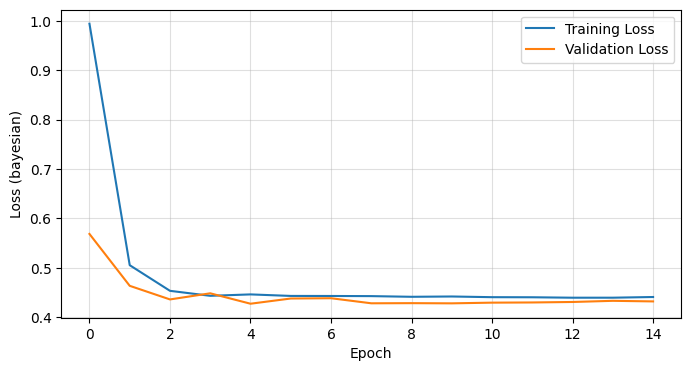

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4)) 
plt.plot(history.history['loss'], label='Training Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.grid(alpha=0.4) 
plt.legend() 
plt.xlabel("Epoch") 
plt.ylabel("Loss (bayesian)")


Text(0, 0.5, 'Loss (bayesian)')

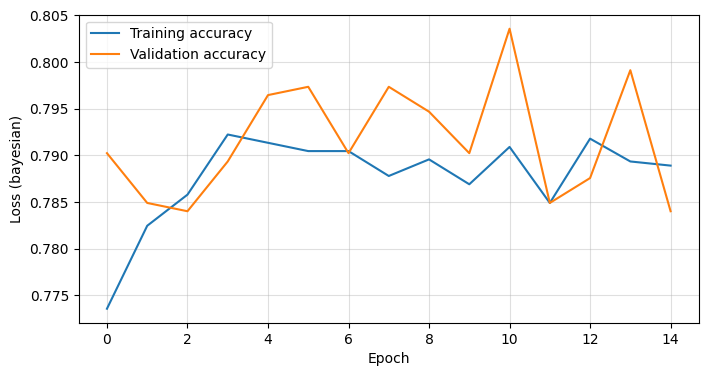

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4)) 
plt.plot(history.history['accuracy'], label='Training accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation accuracy') 
plt.grid(alpha=0.4) 
plt.legend() 
plt.xlabel("Epoch") 
plt.ylabel("Loss (bayesian)")



In [63]:
best_model.save("best_churn_model.keras")

In [64]:
with open('selected_feature.pkl','wb') as f: 
    pickle.dump(selected_features,f)
    

In [65]:
#Prediction
def load_model_comp(): 
    model = tf.keras.models.load_model('/kaggle/working/best_churn_model.keras')

    #load scaler 
    with open('scaler.pkl','rb') as f: 
        scaler = pickle.load(f)

    with open('selected_feature.pkl','rb') as f: 
        selected_features = pickle.load(f)

    return model, scaler, selected_features

In [66]:
X[selected_features].head(3)

,tenure,OnlineSecurity,Contract,MonthlyCharges,TotalCharges
0,1,0,0,29.85,29.85
1,34,1,1,56.95,1889.50
2,2,1,0,53.85,108.15


In [67]:
def pred(): 
    model,scaler, selected_feature = load_model_comp()

    sample_customer = pd.DataFrame([[34, 1, 0, 56.78, 2300]],columns=selected_features) 
    sample_scaled = scaler.transform(sample_customer) 
    prediction = model.predict(sample_scaled)[0][0] 
    print(f"Churn prob:{prediction}") 
    print(f"Will churn :{'yes' if prediction> 0.5 else 'no'}")

pred()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Churn prob:0.19541195034980774
Will churn :no
